# Next-Open Return Predictor — BQuant / BQL (self-diagnosing build)

Ranks current S&P 500 constituents by predicted return from the late-session entry price to the
**next regular-session open**.

## What is different in this build

Every stage prints a diagnostic panel **before** any guard fires, so a failure tells you which
column and which stage caused it rather than surfacing as `Only 0 complete model sessions`.

Specific fixes over v4:

| Problem in v4 | Fix here |
|---|---|
| BQL returned a 552-row **calendar-day** grid per ticker (weekends forward-filled) | `fill='NA'` + the panel is intersected with the benchmark's real trading calendar |
| `px_open` silently NaN → 4 features all-NaN → empty panel, no error until Cell 7 | Open field is **probed across candidate names** before the bulk pull; coverage is asserted at the stage that produces it |
| `dropna(subset=FEATURES)` emptied the panel with no explanation | Features are **auto-pruned** by coverage; the panel can never be emptied silently |
| `g = panel.groupby(...)` created before its columns existed | Groupbys are constructed at point of use |
| Capture window was a 60-second string compare that never fired | Widened, and the actual comparison is on `datetime.time` |
| Benchmark matched by hardcoded `"SPX Index"` string | Benchmark ID resolved from what BQL actually returned |
| Lookbacks (`pct_change(5)`, `rolling(20)`) ran on calendar days | Now run on true trading sessions |

## Still true, and still your problem

- **Survivorship bias.** `bq.univ.members()` returns *today's* index. Backtesting it over 18 months
  only tests companies that survived and stayed in the index. Fix needs point-in-time membership.
- **The proxy entry price is the close, not 15:55.** Bloomberg does not store a historical 15:55
  print retrievable via BQL. Exact 15:55 entries only exist for sessions where you ran the capture
  cell inside the window; everything else is labelled `PX_LAST_PROXY`.
- **Costs.** Close-to-open with 100% daily turnover. `round_trip_cost_bp` is applied in the ranking
  and the walk-forward summary reports the breakeven.

In [1]:
# ============================ Cell 1 — Config, imports, diagnostic helpers
import warnings, sys, traceback, datetime as dtm
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

try:
    import bql
except ImportError as exc:
    raise ImportError("Run inside Bloomberg BQuant; the bql package is required.") from exc

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
NY = "America/New_York"

CFG = {
    "index": "SPX Index",
    "benchmark": "SPX Index",
    "history_calendar_days": 800,        # ~550 trading sessions
    "minimum_price": 5.0,
    "minimum_train_sessions": 160,
    "test_sessions": 350,      # 40 had no statistical power; see Stage 9 power note
    "demean_target": True,     # train on session-demeaned (cross-sectional) target
    "refit_every_days": 21,    # refit monthly; daily refit is ~20x slower for ~no gain
    "sector_neutralise": True, # demean predictions within sector each session
    "earnings_blackout_days": 1,   # exclude |session - announcement| <= N
    "holdout_sessions": 126,   # ~6 months reserved, reported separately
    "top_n": 25,
    "round_trip_cost_bp": 12.0,
    "maximum_abs_target": 0.25,
    "winsor_quantiles": (0.005, 0.995),

    # capture window, exchange-local; compared as real times, not strings
    "capture_start": "15:45",
    "capture_end":   "16:05",
    "snapshot_file": Path("bquant_1555_exact_snapshots.pkl"),

    # BQL behaviour
    "bql_fill": "NA",                    # do NOT forward-fill across non-trading days
    "open_field_candidates": ["px_open", "open", "px_open_1d"],
    "probe_ticker": "IBM US Equity",

    # feature gate
    "min_feature_coverage": 0.60,        # prune any feature below this
    "min_labelled_rows": 5000,
    "target_fallback_to_close": True,    # if no open field exists, target next close instead
    "verbose_bql": True,
}

DIAG = {}


def stage(title):
    print("\n" + "=" * 74)
    print(title)
    print("=" * 74)


def note(msg):
    print(f"   {msg}")


def blocked(msg, hints=()):
    print("\n" + "!" * 74)
    print(f"BLOCKED: {msg}")
    for h in hints:
        print(f"   fix -> {h}")
    print("!" * 74)
    raise RuntimeError(msg)


def coverage_report(df, cols, label):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        note(f"{label}: none of those columns exist")
        return pd.Series(dtype=float)
    cov = df[cols].notna().mean().sort_values()
    note(f"{label} — non-null fraction:")
    for k, v in cov.items():
        mark = "  " if v >= CFG["min_feature_coverage"] else " <-- LOW"
        print(f"      {k:<26} {v:6.4f}{mark}")
    return cov


def frame_report(df, label):
    note(f"{label}: shape={df.shape}")
    if "date" in df.columns and len(df):
        note(f"{label}: {df['date'].min()} -> {df['date'].max()}, "
             f"{df['date'].nunique():,} distinct dates")
    if "ticker" in df.columns and len(df):
        note(f"{label}: {df['ticker'].nunique():,} tickers, "
             f"{len(df) / max(df['ticker'].nunique(), 1):.1f} rows/ticker")


print("Config loaded. Stage diagnostics are ON.")
CFG

Config loaded. Stage diagnostics are ON.


{'index': 'SPX Index',
 'benchmark': 'SPX Index',
 'history_calendar_days': 800,
 'minimum_price': 5.0,
 'minimum_train_sessions': 160,
 'test_sessions': 350,
 'demean_target': True,
 'refit_every_days': 21,
 'sector_neutralise': True,
 'earnings_blackout_days': 1,
 'holdout_sessions': 126,
 'top_n': 25,
 'round_trip_cost_bp': 12.0,
 'maximum_abs_target': 0.25,
 'winsor_quantiles': (0.005, 0.995),
 'capture_start': '15:45',
 'capture_end': '16:05',
 'snapshot_file': PosixPath('bquant_1555_exact_snapshots.pkl'),
 'bql_fill': 'NA',
 'open_field_candidates': ['px_open', 'open', 'px_open_1d'],
 'probe_ticker': 'IBM US Equity',
 'min_feature_coverage': 0.6,
 'min_labelled_rows': 5000,
 'target_fallback_to_close': True,
 'verbose_bql': True}

In [2]:
# ============================ Cell 2 — BQL service, robust extractor, universe
stage("STAGE 2 — BQL service and universe")

bq = bql.Service()
note("bql.Service() OK")


def bql_items(response, labels, verbose=None):
    # Convert a BQL response into a tidy DataFrame. Reports the columns BQL
    # actually returned so a field-name change is visible instead of silent.
    verbose = CFG["verbose_bql"] if verbose is None else verbose
    items = list(response)
    if len(items) != len(labels):
        blocked(f"BQL returned {len(items)} items for {len(labels)} labels: {labels}",
                ["check the dict passed to bql.Request matches `labels`"])

    ignore = {"currency", "revision_date", "as_of_date", "period_end_date",
              "per_security_currency", "orig_ids"}
    frames = []
    for label, item in zip(labels, items):
        raw = item.df().reset_index()
        raw.columns = [str(c).strip().lower() for c in raw.columns]
        raw = raw.rename(columns={"id": "ticker"})
        if verbose:
            note(f"[{label}] BQL columns -> {raw.columns.tolist()}")
        if "ticker" not in raw.columns:
            blocked(f"BQL item '{label}' has no ID column. Got {raw.columns.tolist()}")

        dims = [c for c in ("ticker", "date") if c in raw.columns]
        if label in raw.columns:
            val = label
        else:
            cands = [c for c in raw.columns if c not in dims and c not in ignore]
            if not cands:
                blocked(f"No value column for BQL item '{label}'. Got {raw.columns.tolist()}")
            val = cands[0]
            note(f"[{label}] value column inferred as '{val}' (candidates {cands})")

        f = raw[dims + [val]].rename(columns={val: label}).drop_duplicates(dims, keep="last")
        frames.append(f)

    out = frames[0]
    for f in frames[1:]:
        keys = [c for c in ("ticker", "date") if c in out.columns and c in f.columns]
        if not keys:
            blocked("BQL items share no join key")
        out = out.merge(f, on=keys, how="outer")
    return out


members = bq.univ.members(CFG["index"])
meta_captured_at_ny = pd.Timestamp.now(tz=NY)

meta_response = bq.execute(bql.Request(members, {
    "name": bq.data.name(),
    "sector": bq.data.gics_sector_name(),
    "live_px_last": bq.data.px_last(),
}))
meta = bql_items(meta_response, ["name", "sector", "live_px_last"])
meta = meta[["ticker", "name", "sector", "live_px_last"]].drop_duplicates("ticker")
meta["live_px_last"] = pd.to_numeric(meta["live_px_last"], errors="coerce")

frame_report(meta, "meta")
if len(meta) < 400:
    blocked(f"Only {len(meta)} constituents returned; expected ~500",
            ["check index entitlement", "confirm CFG['index'] resolves in BQL"])

bench_live_resp = bq.execute(bql.Request(CFG["benchmark"], {"live_px_last": bq.data.px_last()}))
benchmark_live = bql_items(bench_live_resp, ["live_px_last"])[["ticker", "live_px_last"]]
benchmark_live["live_px_last"] = pd.to_numeric(benchmark_live["live_px_last"], errors="coerce")

# Resolve the benchmark ID from what BQL actually returned, not the config string.
BENCH_ID = benchmark_live["ticker"].iloc[0]
note(f"benchmark ID resolved as {BENCH_ID!r} (config asked for {CFG['benchmark']!r})")
if BENCH_ID != CFG["benchmark"]:
    note("NOTE: these differ. Using the BQL-returned ID everywhere downstream.")

live_snapshot_meta = pd.concat(
    [meta[["ticker", "live_px_last"]], benchmark_live], ignore_index=True
).dropna(subset=["live_px_last"]).drop_duplicates("ticker", keep="last")

DIAG["n_constituents"] = len(meta)
note(f"universe: {len(meta):,} stocks; live snapshot rows: {len(live_snapshot_meta):,}")
display(meta.head())


STAGE 2 — BQL service and universe
   bql.Service() OK
   [name] BQL columns -> ['ticker', 'name']
   [sector] BQL columns -> ['ticker', 'sector']
   [live_px_last] BQL columns -> ['ticker', 'date', 'currency', 'live_px_last']
   meta: shape=(503, 4)
   meta: 503 tickers, 1.0 rows/ticker
   [live_px_last] BQL columns -> ['ticker', 'date', 'currency', 'live_px_last']
   benchmark ID resolved as 'SPX Index' (config asked for 'SPX Index')
   universe: 503 stocks; live snapshot rows: 504


,ticker,name,sector,live_px_last
0,A UN Equity,Agilent Technologies Inc,Health Care,156.300003
1,AAPL UW Equity,Apple Inc,Information Technology,311.299988
2,ABBV UN Equity,AbbVie Inc,Health Care,261.829987
3,ABNB UW Equity,Airbnb Inc,Consumer Discretionary,185.000000
4,ABT UN Equity,Abbott Laboratories,Health Care,114.139999


In [3]:
# ============================ Cell 3 — Probe which open-price field actually works
stage("STAGE 3 — Open-price field probe")
# v4 assumed bq.data.px_open() returns data. When it silently returns NaN, four
# features go all-NaN and the panel empties with no error until the model cell.
# Probe on one ticker, cheaply, before pulling 500 names.

now_ny = pd.Timestamp.now(tz=NY)
end_date = now_ny.date().isoformat()
start_date = (now_ny.normalize() - pd.Timedelta(days=CFG["history_calendar_days"])).date().isoformat()
probe_start = (now_ny.normalize() - pd.Timedelta(days=90)).date().isoformat()

OPEN_FIELD = None
probe_range = bq.func.range(probe_start, end_date)

for cand in CFG["open_field_candidates"]:
    fn = getattr(bq.data, cand, None)
    if fn is None:
        note(f"{cand:<12} : not an attribute of bq.data")
        continue
    try:
        resp = bq.execute(bql.Request(CFG["probe_ticker"],
                                      {cand: fn(dates=probe_range, fill=CFG["bql_fill"])}))
        d = bql_items(resp, [cand], verbose=False)
        vals = pd.to_numeric(d[cand], errors="coerce")
        cov = float(vals.notna().mean()) if len(vals) else 0.0
        note(f"{cand:<12} : {len(d):>4} rows, coverage {cov:.3f}, sample {vals.dropna().head(2).tolist()}")
        if cov > 0.5:
            OPEN_FIELD = cand
            break
    except Exception as e:
        note(f"{cand:<12} : {type(e).__name__}: {e}")

DIAG["open_field"] = OPEN_FIELD or "(none)"

if OPEN_FIELD:
    note(f"USING OPEN FIELD -> {OPEN_FIELD!r}")
    TARGET_MODE = "NEXT_OPEN"
elif CFG["target_fallback_to_close"]:
    print("\n" + "*" * 74)
    print("WARNING: no working open-price field. Falling back to NEXT CLOSE as the target.")
    print("This changes the strategy from close->open to close->close. Results are NOT")
    print("comparable to an overnight-gap strategy. Set target_fallback_to_close=False to")
    print("hard-fail instead.")
    print("*" * 74)
    TARGET_MODE = "NEXT_CLOSE"
else:
    blocked("No usable open-price field in BQL",
            ["run FLDS <GO> on PX_OPEN and confirm entitlement",
             "extend CFG['open_field_candidates']",
             "set CFG['target_fallback_to_close']=True to proceed on close-to-close"])

note(f"TARGET_MODE = {TARGET_MODE}")


STAGE 3 — Open-price field probe
   px_open      :   91 rows, coverage 0.681, sample [262.05, 254.55]
   USING OPEN FIELD -> 'px_open'
   TARGET_MODE = NEXT_OPEN


In [4]:
# ============================ Cell 4 — History pull + trading-calendar repair
stage("STAGE 4 — Historical prices")

date_range = bq.func.range(start_date, end_date)
history_items = {"px_last": bq.data.px_last(dates=date_range, fill=CFG["bql_fill"])}
if OPEN_FIELD:
    history_items["px_open"] = getattr(bq.data, OPEN_FIELD)(dates=date_range, fill=CFG["bql_fill"])
labels = list(history_items.keys())

note(f"requesting {labels} from {start_date} to {end_date}")
equity_history = bql_items(bq.execute(bql.Request(members, history_items)), labels)
benchmark_history = bql_items(bq.execute(bql.Request(CFG["benchmark"], history_items)), labels,
                              verbose=False)

history = pd.concat([equity_history, benchmark_history], ignore_index=True)
history["date"] = pd.to_datetime(history["date"], errors="coerce", utc=True) \
                    .dt.tz_convert(None).dt.normalize()
for c in labels:
    history[c] = pd.to_numeric(history[c], errors="coerce")
history = history.dropna(subset=["ticker", "date"])
history = history.drop_duplicates(["ticker", "date"], keep="last")
history = history.sort_values(["ticker", "date"]).reset_index(drop=True)

note("--- RAW, before calendar repair ---")
frame_report(history, "history(raw)")
coverage_report(history, labels, "history(raw)")
wk = history["date"].dt.dayofweek.value_counts().sort_index()
note(f"rows by weekday (0=Mon,5=Sat,6=Sun): {wk.to_dict()}")
DIAG["raw_rows_per_ticker"] = len(history) / max(history["ticker"].nunique(), 1)

# --- calendar repair -------------------------------------------------------
# v4 got 552 rows/ticker over 550 calendar days: BQL returned a calendar grid.
# Real sessions = dates on which the benchmark itself printed a price.
bench_rows = history[history["ticker"] == BENCH_ID]
if bench_rows.empty:
    idx_like = [t for t in history["ticker"].unique() if "Index" in str(t)][:10]
    blocked(f"No rows for benchmark {BENCH_ID!r}",
            [f"tickers containing 'Index': {idx_like}",
             "set CFG['benchmark'] to one of those"])

trading_days = pd.Index(sorted(bench_rows.loc[bench_rows["px_last"].notna(), "date"].unique()))
note(f"benchmark trading sessions: {len(trading_days):,}")

before = len(history)
history = history[history["date"].isin(trading_days)]
history = history[history["px_last"].notna()]
note(f"calendar repair: {before:,} -> {len(history):,} rows "
     f"(removed {before - len(history):,} non-trading / empty rows)")

note("--- REPAIRED ---")
frame_report(history, "history")
coverage_report(history, labels, "history")
wk = history["date"].dt.dayofweek.value_counts().sort_index()
note(f"rows by weekday: {wk.to_dict()}")
if set(wk.index) & {5, 6}:
    note("WARNING: weekend rows still present — benchmark calendar looks wrong")

if OPEN_FIELD:
    stk = history[history["ticker"] != BENCH_ID]
    bm = history[history["ticker"] == BENCH_ID]
    note(f"stock px_open coverage    : {stk['px_open'].notna().mean():.4f}")
    note(f"benchmark px_open coverage: {bm['px_open'].notna().mean():.4f}")
    if bm["px_open"].notna().mean() < 0.5:
        note("WARNING: benchmark open is sparse — market_* intraday features will be pruned")

DIAG["n_sessions"] = int(history["date"].nunique())
DIAG["rows_per_ticker"] = len(history) / max(history["ticker"].nunique(), 1)
note(f"sessions={DIAG['n_sessions']}, rows/ticker={DIAG['rows_per_ticker']:.1f}")

need = CFG["minimum_train_sessions"] + CFG["test_sessions"] + 25
if DIAG["n_sessions"] < need:
    blocked(f"Only {DIAG['n_sessions']} trading sessions; need {need}",
            [f"raise CFG['history_calendar_days'] (currently {CFG['history_calendar_days']})",
             "or lower minimum_train_sessions / test_sessions"])
print(f"\nHistory OK: {history['date'].min().date()} -> {history['date'].max().date()}, "
      f"{len(history):,} rows")


STAGE 4 — Historical prices
   requesting ['px_last', 'px_open'] from 2024-06-11 to 2026-08-20
   [px_last] BQL columns -> ['ticker', 'date', 'currency', 'px_last']
   [px_open] BQL columns -> ['ticker', 'date', 'currency', 'px_open']
   --- RAW, before calendar repair ---
   history(raw): shape=(403704, 4)
   history(raw): 2024-06-11 00:00:00 -> 2026-08-20 00:00:00, 801 distinct dates
   history(raw): 504 tickers, 801.0 rows/ticker
   history(raw) — non-null fraction:
      px_open                    0.6785  
      px_last                    0.6785  
   rows by weekday (0=Mon,5=Sat,6=Sun): {0: 57456, 1: 57960, 2: 57960, 3: 57960, 4: 57456, 5: 57456, 6: 57456}
   benchmark trading sessions: 550
   calendar repair: 403,704 -> 273,905 rows (removed 129,799 non-trading / empty rows)
   --- REPAIRED ---
   history: shape=(273905, 4)
   history: 2024-06-11 00:00:00 -> 2026-08-20 00:00:00, 550 distinct dates
   history: 504 tickers, 543.5 rows/ticker
   history — non-null fraction:
      px

In [5]:
# ============================ Cell 5 — Exact late-session snapshot capture
stage("STAGE 5 — 15:55 snapshot capture")
# v4 compared "%H:%M" strings with start == end == "15:55", a 60-second window that
# in practice never fired, so every entry silently fell back to the close proxy.

snapshot_columns = ["ticker", "session", "entry_price", "captured_at_ny"]
if CFG["snapshot_file"].exists():
    exact_snapshots = pd.read_pickle(CFG["snapshot_file"])
    missing = [c for c in snapshot_columns if c not in exact_snapshots.columns]
    if missing:
        note(f"snapshot file malformed (missing {missing}); starting a fresh one")
        exact_snapshots = pd.DataFrame(columns=snapshot_columns)
else:
    exact_snapshots = pd.DataFrame(columns=snapshot_columns)
    note(f"no snapshot file at {CFG['snapshot_file']}; starting fresh")

capture_time_ny = meta_captured_at_ny
t_now = capture_time_ny.time()
t_lo = dtm.time.fromisoformat(CFG["capture_start"])
t_hi = dtm.time.fromisoformat(CFG["capture_end"])
inside = t_lo <= t_now <= t_hi
note(f"BQL snapshot clock {t_now.strftime('%H:%M:%S')} NY; "
     f"window {CFG['capture_start']}-{CFG['capture_end']} -> "
     f"{'INSIDE' if inside else 'OUTSIDE'}")

if inside:
    captured = live_snapshot_meta.rename(columns={"live_px_last": "entry_price"}).copy()
    captured["session"] = capture_time_ny.tz_localize(None).normalize()
    captured["captured_at_ny"] = capture_time_ny.isoformat()
    captured = captured.dropna(subset=["entry_price"])
    exact_snapshots = pd.concat([exact_snapshots, captured], ignore_index=True)
    exact_snapshots = exact_snapshots.sort_values("captured_at_ny") \
                                     .drop_duplicates(["ticker", "session"], keep="last")
    exact_snapshots.to_pickle(CFG["snapshot_file"])
    note(f"captured {len(captured):,} exact entries at {capture_time_ny:%Y-%m-%d %H:%M:%S %Z}")
else:
    note("no exact capture this run; entries will be labelled PX_LAST_PROXY")

if len(exact_snapshots):
    exact_snapshots["session"] = pd.to_datetime(exact_snapshots["session"], errors="coerce") \
                                   .dt.tz_localize(None).dt.normalize()
    exact_snapshots["entry_price"] = pd.to_numeric(exact_snapshots["entry_price"], errors="coerce")

DIAG["exact_snapshot_rows"] = len(exact_snapshots)
note(f"stored exact stock-session observations: {len(exact_snapshots):,}")


STAGE 5 — 15:55 snapshot capture
   no snapshot file at bquant_1555_exact_snapshots.pkl; starting fresh
   BQL snapshot clock 19:27:36 NY; window 15:45-16:05 -> OUTSIDE
   no exact capture this run; entries will be labelled PX_LAST_PROXY
   stored exact stock-session observations: 0


In [6]:
# ============================ Cell 5b — Earnings blackout dates (best effort)
stage("STAGE 5b — Earnings announcement dates")
# Diagnostic from the last run: decile spread (2.5bp) was far below what the IC
# (0.019) implies (~10bp). Prime suspect is event risk in the extremes -- names
# gapping on earnings, which no price feature can anticipate.

EARNINGS_AVAILABLE = False
earnings_dates = pd.DataFrame(columns=["ticker", "ann_date"])


def _extract_dates(df, label):
    # Find any datetime-like column in a BQL frame and return (ticker, ann_date).
    out = []
    for c in df.columns:
        if c in ("ticker",):
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            continue          # numerics coerce to 1970 epoch dates; not real dates
        s = pd.to_datetime(df[c], errors="coerce")
        if s.notna().mean() > 0.5 and s.dropna().dt.year.between(1990, 2100).mean() > 0.9:
            out.append(pd.DataFrame({"ticker": df["ticker"], "ann_date": s}))
    if not out:
        return None
    return pd.concat(out, ignore_index=True).dropna().drop_duplicates()


_attempts = [
    ("earn_ann_dt_time_hist_with_eps", lambda: bq.data.earn_ann_dt_time_hist_with_eps()),
    ("announcement_dt", lambda: bq.data.announcement_dt(
        fa_period_type="Q", fa_period_offset=bq.func.range(-12, 0))),
    ("announcement_dt_simple", lambda: bq.data.announcement_dt()),
]

for name, builder in _attempts:
    try:
        fld = builder()
    except Exception as e:
        note(f"{name:<32}: build failed -> {type(e).__name__}: {e}")
        continue
    try:
        resp = bq.execute(bql.Request(members, {name: fld}))
        # NB: parse the item directly. bql_items() de-duplicates to one row per
        # ticker, which would collapse an entire earnings history to one date.
        raw = list(resp)[0].df().reset_index()
        raw.columns = [str(x).strip().lower() for x in raw.columns]
        raw = raw.rename(columns={"id": "ticker"})
        note(f"{name:<32}: raw columns {raw.columns.tolist()}, {len(raw):,} rows")
        got = _extract_dates(raw, name)
        if got is None or got.empty:
            note(f"{name:<32}: no date-like column returned")
            continue
        got["ann_date"] = got["ann_date"].dt.tz_localize(None).dt.normalize()
        note(f"{name:<32}: {len(got):,} dates, {got['ticker'].nunique():,} tickers, "
             f"{got['ann_date'].min().date()} -> {got['ann_date'].max().date()}")
        earnings_dates = got
        EARNINGS_AVAILABLE = True
        note(f"USING EARNINGS SOURCE -> {name!r}")
        break
    except Exception as e:
        note(f"{name:<32}: {type(e).__name__}: {e}")

if not EARNINGS_AVAILABLE:
    print("\n" + "*" * 74)
    print("WARNING: no historical earnings dates available via BQL.")
    print("The earnings-exclusion variant in Stage 9 will be SKIPPED and reported as")
    print("'not tested'. Sector-neutralisation is unaffected.")
    print("*" * 74)

DIAG["earnings_available"] = EARNINGS_AVAILABLE
DIAG["earnings_rows"] = len(earnings_dates)


STAGE 5b — Earnings announcement dates
   earn_ann_dt_time_hist_with_eps  : build failed -> AttributeError: No BQL data item named 'earn_ann_dt_time_hist_with_eps'
   announcement_dt                 : build failed -> InvalidParameterGroupError: No parameter group of "ANNOUNCEMENT_DT" can accomodate the given set of parameters.

Parameter group "CRA2_PARAMGROUP7198231709715802570" does not work because: 'fa_period_type' is not a valid parameter name
Parameter group "CRA2_PARAMGROUP3362291445240178643" does not work because: 'fa_period_type' is not a valid parameter name
   announcement_dt_simple          : raw columns ['ticker', 'announcement_dt_simple'], 503 rows
   announcement_dt_simple          : 503 dates, 503 tickers, 2026-04-28 -> 2026-08-19
   USING EARNINGS SOURCE -> 'announcement_dt_simple'


In [7]:
# ============================ Cell 6 — Panel, target, features
stage("STAGE 6 — Panel construction")

panel = history.rename(columns={"date": "session", "px_last": "close_proxy"}).copy()
if OPEN_FIELD:
    panel = panel.rename(columns={"px_open": "session_open"})
else:
    panel["session_open"] = np.nan

if len(exact_snapshots):
    panel = panel.merge(exact_snapshots[["ticker", "session", "entry_price"]],
                        on=["ticker", "session"], how="left")
else:
    panel["entry_price"] = np.nan
panel["entry_source"] = np.where(panel["entry_price"].notna(), "EXACT_1555", "PX_LAST_PROXY")
panel["entry_price"] = panel["entry_price"].fillna(panel["close_proxy"])
panel = panel.sort_values(["ticker", "session"]).reset_index(drop=True)

# --- next-session calendar -------------------------------------------------
market_sessions = np.array(sorted(panel.loc[panel["ticker"] == BENCH_ID, "session"].unique()))
if len(market_sessions) < 2:
    blocked("benchmark produced no usable trading calendar")
calendar = pd.DataFrame({"session": market_sessions[:-1], "next_session": market_sessions[1:]})
panel = panel.merge(calendar, on="session", how="left")

target_col = "session_open" if TARGET_MODE == "NEXT_OPEN" else "close_proxy"
nxt = panel[["ticker", "session", target_col]].rename(
    columns={"session": "next_session", target_col: "next_px"})
panel = panel.merge(nxt, on=["ticker", "next_session"], how="left")
panel["target_next_open"] = panel["next_px"] / panel["entry_price"] - 1

note(f"target = next {target_col} / entry_price - 1   [{TARGET_MODE}]")
for c in ["entry_price", "session_open", "next_px", "target_next_open"]:
    note(f"panel.{c:<18} non-null {panel[c].notna().mean():.4f}")

# --- features (groupbys built at point of use; v4 built one before its columns existed)
panel["ret_intraday"] = panel["entry_price"] / panel["session_open"] - 1
panel["ret_1d"]  = panel.groupby("ticker")["entry_price"].pct_change(1, fill_method=None)
panel["ret_5d"]  = panel.groupby("ticker")["entry_price"].pct_change(5, fill_method=None)
panel["ret_20d"] = panel.groupby("ticker")["entry_price"].pct_change(20, fill_method=None)
panel["ma20_gap"] = panel["entry_price"] / panel.groupby("ticker")["entry_price"] \
                        .transform(lambda s: s.rolling(20, min_periods=15).mean()) - 1
panel["rv_10d"] = panel.groupby("ticker")["ret_1d"] \
                       .transform(lambda s: s.rolling(10, min_periods=8).std()) * np.sqrt(252)
panel["rv_20d"] = panel.groupby("ticker")["ret_1d"] \
                       .transform(lambda s: s.rolling(20, min_periods=15).std()) * np.sqrt(252)

bench = panel[panel["ticker"] == BENCH_ID][
    ["session", "ret_intraday", "ret_1d", "ret_5d", "rv_20d"]].copy()
bench = bench.rename(columns={c: f"market_{c}" for c in bench.columns if c != "session"})
panel = panel.merge(bench, on="session", how="left")
panel["relative_intraday"] = panel["ret_intraday"] - panel["market_ret_intraday"]
panel["relative_5d"] = panel["ret_5d"] - panel["market_ret_5d"]

for c in ["ret_intraday", "ret_1d", "ret_5d", "ret_20d", "ma20_gap", "rv_20d"]:
    panel[f"rank_{c}"] = panel.groupby("session")[c].rank(pct=True) - 0.5

model_df = panel[panel["ticker"] != BENCH_ID].merge(
    meta[["ticker", "name", "sector"]], on="ticker", how="inner")

# earnings blackout flag (leakage-free: announcement dates are known ex ante)
if EARNINGS_AVAILABLE and len(earnings_dates):
    bl = CFG["earnings_blackout_days"]
    ed = earnings_dates.copy()
    spans = [ed.assign(session=ed["ann_date"] + pd.Timedelta(days=k))[["ticker", "session"]]
             for k in range(-bl, bl + 1)]
    flag = pd.concat(spans, ignore_index=True).drop_duplicates()
    flag["is_earnings"] = True
    model_df = model_df.merge(flag, on=["ticker", "session"], how="left")
    model_df["is_earnings"] = model_df["is_earnings"].fillna(False).astype(bool)
    note(f"earnings-window stock-sessions flagged: {int(model_df['is_earnings'].sum()):,}"
         f" ({model_df['is_earnings'].mean():.2%})")
else:
    model_df["is_earnings"] = False
    note("no earnings flag available; is_earnings set False everywhere")
bad = model_df["target_next_open"].abs() > CFG["maximum_abs_target"]
model_df.loc[bad, "target_next_open"] = np.nan
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# Train on the cross-sectionally demeaned target: a dollar-neutral book cannot
# harvest the common overnight gap, so predicting it wastes model capacity.
# Rank IC is unchanged by a per-session shift, so evaluation is unaffected.
if CFG["demean_target"]:
    model_df["target_train"] = model_df["target_next_open"] - \
        model_df.groupby("session")["target_next_open"].transform("mean")
    note("target_train = session-demeaned target_next_open")
else:
    model_df["target_train"] = model_df["target_next_open"]
    note("target_train = raw target_next_open")

note(f"extreme/corporate-action targets nulled: {int(bad.sum()):,}")
frame_report(model_df.rename(columns={"session": "date"}), "model_df")
DIAG["model_df_rows"] = len(model_df)


STAGE 6 — Panel construction
   target = next session_open / entry_price - 1   [NEXT_OPEN]
   panel.entry_price        non-null 1.0000
   panel.session_open       non-null 1.0000
   panel.next_px            non-null 0.9982
   panel.target_next_open   non-null 0.9982
   earnings-window stock-sessions flagged: 1,443 (0.53%)
   target_train = session-demeaned target_next_open
   extreme/corporate-action targets nulled: 31
   model_df: shape=(273355, 32)
   model_df: 2024-06-11 00:00:00 -> 2026-08-20 00:00:00, 550 distinct dates
   model_df: 503 tickers, 543.4 rows/ticker


In [8]:
# ============================ Cell 7 — Feature health gate (auto-prune)
stage("STAGE 7 — Feature health gate")
# The v4 failure mode: dropna(subset=ALL_FEATURES) silently emptied the panel because
# one column was 100% NaN. Here low-coverage features are pruned and reported instead.

CANDIDATE_FEATURES = [
    "ret_intraday", "ret_1d", "ret_5d", "ret_20d", "ma20_gap", "rv_10d", "rv_20d",
    "market_ret_intraday", "market_ret_1d", "market_ret_5d", "market_rv_20d",
    "relative_intraday", "relative_5d", "rank_ret_intraday", "rank_ret_1d",
    "rank_ret_5d", "rank_ret_20d", "rank_ma20_gap", "rank_rv_20d",
]

absent = [c for c in CANDIDATE_FEATURES if c not in model_df.columns]
if absent:
    note(f"not present in model_df, skipped: {absent}")
present = [c for c in CANDIDATE_FEATURES if c in model_df.columns]

cov = coverage_report(model_df, present + ["target_next_open", "target_train"], "candidate features")

FEATURES = [c for c in present if cov.get(c, 0.0) >= CFG["min_feature_coverage"]]
pruned = [c for c in present if c not in FEATURES]
if pruned:
    print()
    note(f"PRUNED {len(pruned)} low-coverage feature(s): {pruned}")
    if not OPEN_FIELD:
        note("(expected: no open field, so all intraday-derived features are empty)")
if not FEATURES:
    blocked("Every candidate feature failed the coverage gate",
            ["inspect the coverage table above",
             "lower CFG['min_feature_coverage']"])

note(f"KEEPING {len(FEATURES)} features: {FEATURES}")

# --- cumulative row loss, so an empty panel is never a mystery -------------
print()
note("cumulative row loss through dropna:")
surv = model_df.copy()
culprit = None
for c in FEATURES + ["target_next_open", "target_train"]:
    b = len(surv)
    surv = surv.dropna(subset=[c])
    if len(surv) < b:
        print(f"      {c:<26} {b:>9,} -> {len(surv):>9,}  (-{b - len(surv):,})")
    if len(surv) == 0:
        culprit = c
        break

if culprit:
    blocked(f"Panel emptied at feature '{culprit}'",
            [f"'{culprit}' coverage is {cov.get(culprit, float('nan')):.4f}",
             "raise CFG['min_feature_coverage'] to prune it automatically"])

labelled = surv.copy()
sessions = np.array(sorted(labelled["session"].unique()))
frame_report(labelled.rename(columns={"session": "date"}), "labelled")
note(f"complete sessions: {len(sessions):,}")

# --- adapt the walk-forward split to what actually exists ------------------
required = CFG["minimum_train_sessions"] + CFG["test_sessions"]
if len(sessions) < required:
    if len(sessions) < 60:
        blocked(f"Only {len(sessions)} complete sessions — too few to model",
                ["see the cumulative row-loss table above for what is dropping rows",
                 "raise CFG['history_calendar_days']"])
    TEST_SESSIONS = max(10, int(len(sessions) * 0.25))
    MIN_TRAIN = len(sessions) - TEST_SESSIONS
    note(f"ADAPTED: {len(sessions)} sessions available (< {required} configured); "
         f"using min_train={MIN_TRAIN}, test={TEST_SESSIONS}")
else:
    TEST_SESSIONS = CFG["test_sessions"]
    MIN_TRAIN = CFG["minimum_train_sessions"]
    note(f"split: min_train={MIN_TRAIN}, test={TEST_SESSIONS}")

DIAG["n_features"] = len(FEATURES)
DIAG["labelled_rows"] = len(labelled)
DIAG["complete_sessions"] = len(sessions)


STAGE 7 — Feature health gate
   candidate features — non-null fraction:
      ret_20d                    0.9632  
      rank_ret_20d               0.9632  
      rank_rv_20d                0.9724  
      rv_20d                     0.9724  
      market_rv_20d              0.9730  
      rank_ma20_gap              0.9742  
      ma20_gap                   0.9742  
      rv_10d                     0.9853  
      relative_5d                0.9908  
      ret_5d                     0.9908  
      rank_ret_5d                0.9908  
      market_ret_5d              0.9910  
      target_next_open           0.9980  
      target_train               0.9980  
      ret_1d                     0.9982  
      rank_ret_1d                0.9982  
      market_ret_1d              0.9982  
      rank_ret_intraday          1.0000  
      ret_intraday               1.0000  
      relative_intraday          1.0000  
      market_ret_intraday        1.0000  
   KEEPING 19 features: ['ret_intraday', 're

In [9]:
# ============================ Cell 8 — Scoring session audit
stage("STAGE 8 — Latest scoring session")

session_counts = model_df.groupby("session")["entry_price"].count()
min_cov = int(np.ceil(0.85 * meta["ticker"].nunique()))
eligible = session_counts.index[session_counts >= min_cov]
if len(eligible) == 0:
    note(f"best session coverage: {session_counts.max()} vs required {min_cov}")
    blocked("No session reaches 85% universe coverage")

latest_session = eligible.max()
latest = model_df[model_df["session"] == latest_session]

audit = pd.Series({
    "latest_scoring_session": latest_session,
    "target_mode": TARGET_MODE,
    "open_field": OPEN_FIELD or "(none)",
    "eligible_constituents": meta["ticker"].nunique(),
    "latest_entry_obs": int(latest["entry_price"].notna().sum()),
    "latest_exact_1555": int((latest["entry_source"] == "EXACT_1555").sum()),
    "all_exact_1555": int((model_df["entry_source"] == "EXACT_1555").sum()),
    "all_proxy": int((model_df["entry_source"] == "PX_LAST_PROXY").sum()),
    "trading_sessions": DIAG["n_sessions"],
    "rows_per_ticker": round(DIAG["rows_per_ticker"], 1),
    "features_kept": DIAG["n_features"],
    "labelled_rows": DIAG["labelled_rows"],
    "complete_sessions": DIAG["complete_sessions"],
    "duplicate_ticker_sessions": int(model_df.duplicated(["ticker", "session"]).sum()),
    "nonpositive_entry_prices": int((model_df["entry_price"].dropna() <= 0).sum()),
})
display(audit.to_frame("value"))

if audit["duplicate_ticker_sessions"]:
    blocked("Duplicate ticker-session rows")
if audit["nonpositive_entry_prices"]:
    blocked("Non-positive entry prices")
staleness = (now_ny.tz_localize(None).normalize() - latest_session).days
note(f"latest session is {staleness} calendar days old")
if staleness > 5:
    blocked(f"Latest scoring session stale by {staleness} days")


STAGE 8 — Latest scoring session


,value
latest_scoring_session,2026-08-20 00:00:00
target_mode,NEXT_OPEN
open_field,px_open
eligible_constituents,503
latest_entry_obs,503
latest_exact_1555,0
all_exact_1555,0
all_proxy,273355
trading_sessions,550
rows_per_ticker,543.5


   latest session is 0 calendar days old



STAGE 9 — Walk-forward evaluation
   refit    1/350 @ 2025-03-28 (179 train sessions)
   refit   22/350 @ 2025-04-29 (200 train sessions)
   refit   43/350 @ 2025-05-29 (221 train sessions)
   refit   64/350 @ 2025-06-30 (242 train sessions)
   refit   85/350 @ 2025-07-30 (263 train sessions)
   refit  106/350 @ 2025-08-28 (284 train sessions)
   refit  127/350 @ 2025-09-29 (305 train sessions)
   refit  148/350 @ 2025-10-28 (326 train sessions)
   refit  169/350 @ 2025-11-26 (347 train sessions)
   refit  190/350 @ 2025-12-29 (368 train sessions)
   refit  211/350 @ 2026-01-29 (389 train sessions)
   refit  232/350 @ 2026-03-02 (410 train sessions)
   refit  253/350 @ 2026-03-31 (431 train sessions)
   refit  274/350 @ 2026-04-30 (452 train sessions)
   refit  295/350 @ 2026-06-01 (473 train sessions)
   refit  316/350 @ 2026-07-01 (494 train sessions)
   refit  337/350 @ 2026-07-31 (515 train sessions)
   test days attempted 350, skipped 0, scored 350
   earnings-window rows exclude

,sessions,mean_IC,IC_sd,IC_t,pos_IC_rate,sign_test_z,gross_bp,net_bp,ls_t
raw,350.0,0.0226,0.2222,1.9021,0.5514,1.9243,7.7005,-4.2995,1.3212
sector-neutral,350.0,0.0222,0.1531,2.7132,0.5543,2.0312,5.9534,-6.0466,1.3103
ex-earnings,350.0,0.0231,0.2237,1.9311,0.5514,1.9243,8.4717,-3.5283,1.4467
ex-earn + sector-neutral,350.0,0.0226,0.1545,2.7377,0.5600,2.2450,6.4023,-5.5977,1.4122


IC sd under the null (1/sqrt(n_names)) = 0.0448
An IC_sd far above that is factor structure, not sampling noise.
Round-trip cost assumed: 12.0 bp

Decile monotonicity — variant 'ex-earn + sector-neutral':


,mean_bp,n
decile,,
1,1.64,17391
2,1.19,17352
3,1.47,17212
4,1.23,17328
5,2.13,17278
6,3.83,17254
7,3.85,17226
8,5.06,17314
9,5.22,17250


D10-D1 = 6.27 bp gross
A real signal steps across buckets; a spread driven only by D1/D10 is event noise.

POWER ('ex-earn + sector-neutral'): daily IC sd = 0.1545 over 350 sessions.
   true IC of 0.01 at t=2 -> NOT detectable (need ~955)
   true IC of 0.02 at t=2 -> detectable
   true IC of 0.03 at t=2 -> detectable

HOLDOUT (last 126 sessions, from 2026-02-19):
   tuning window  n= 224  IC=+0.0362  t=+3.47  gross=+10.47bp
   HELD OUT       n= 126  IC=-0.0015  t=-0.11  gross=-0.84bp
   If HELD OUT collapses versus the tuning window, the signal is fitted.

VERDICT: DOES NOT survive costs at the configured round-trip


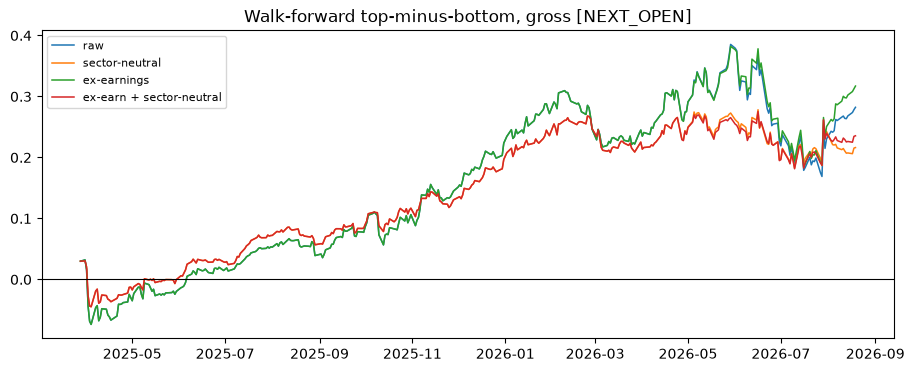

In [10]:
# ============================ Cell 9 — Walk-forward + variant comparison
stage("STAGE 9 — Walk-forward evaluation")


def make_model():
    return HistGradientBoostingRegressor(
        loss="squared_error", learning_rate=0.045, max_iter=180,
        max_leaf_nodes=15, min_samples_leaf=80, l2_regularization=2.0,
        random_state=42,
    )


keep_cols = ["session", "ticker", "sector", "target_next_open"]
if "is_earnings" in labelled.columns:
    keep_cols.append("is_earnings")

parts, skipped, mdl, last_fit = [], 0, None, -10 ** 9
test_days = sessions[-TEST_SESSIONS:]
for i, test_day in enumerate(test_days):
    train = labelled[labelled["session"] < test_day]
    test = labelled[labelled["session"] == test_day].copy()
    if train["session"].nunique() < MIN_TRAIN or test.empty:
        skipped += 1
        continue
    if mdl is None or (i - last_fit) >= CFG["refit_every_days"]:
        lo, hi = train["target_train"].quantile(CFG["winsor_quantiles"])
        mdl = make_model().fit(train[FEATURES], train["target_train"].clip(lo, hi))
        last_fit = i
        print(f"   refit {i + 1:>4}/{len(test_days)} @ "
              f"{pd.Timestamp(test_day).date()} "
              f"({train['session'].nunique()} train sessions)", flush=True)
    test["prediction"] = mdl.predict(test[FEATURES])
    parts.append(test[keep_cols + ["prediction"]])

note(f"test days attempted {len(test_days)}, skipped {skipped}, scored {len(parts)}")
if not parts:
    blocked("Walk-forward produced no predictions",
            [f"MIN_TRAIN={MIN_TRAIN} but only {len(sessions)} sessions exist",
             "lower CFG['minimum_train_sessions']"])

oos = pd.concat(parts, ignore_index=True)

# --- sector-neutralised prediction ----------------------------------------
# Last run: daily IC sd was 0.223 vs a null of 1/sqrt(503)=0.045, i.e. 96% of the
# IC variance was common factor structure, not sampling noise. Removing sector
# exposure should shrink that sd and raise the t-stat on the same raw signal.
oos["pred_sn"] = oos["prediction"] - oos.groupby(["session", "sector"])["prediction"] \
                                        .transform("mean")


def variant_stats(df, pred_col, label):
    rows = []
    for day, d in df.groupby("session", sort=True):
        if len(d) < 20:
            continue
        n = max(1, len(d) // 10)
        rows.append({
            "session": day,
            "ic": d[pred_col].corr(d["target_next_open"], method="spearman"),
            "top": d.nlargest(n, pred_col)["target_next_open"].mean(),
            "bot": d.nsmallest(n, pred_col)["target_next_open"].mean(),
        })
    if not rows:
        return None, None
    dd = pd.DataFrame(rows)
    dd["ls"] = dd["top"] - dd["bot"]
    n = len(dd)
    sd = dd["ic"].std()
    pos = (dd["ic"] > 0).sum()
    z_sign = (pos - n / 2) / np.sqrt(n / 4)
    return pd.Series({
        "sessions": n,
        "mean_IC": dd["ic"].mean(),
        "IC_sd": sd,
        "IC_t": dd["ic"].mean() / sd * np.sqrt(n) if sd else np.nan,
        "pos_IC_rate": pos / n,
        "sign_test_z": z_sign,
        "gross_bp": dd["ls"].mean() * 10_000,
        "net_bp": dd["ls"].mean() * 10_000 - CFG["round_trip_cost_bp"],
        "ls_t": dd["ls"].mean() / dd["ls"].std() * np.sqrt(n) if dd["ls"].std() else np.nan,
    }, name=label), dd


variants = {}
daily_store = {}
for label, subset, col in [
    ("raw", oos, "prediction"),
    ("sector-neutral", oos, "pred_sn"),
]:
    s, dd = variant_stats(subset, col, label)
    if s is not None:
        variants[label] = s
        daily_store[label] = dd

if "is_earnings" in oos.columns:
    oos["is_earnings"] = oos["is_earnings"].fillna(False).astype(bool)
    clean = oos[~oos["is_earnings"]]
    note(f"earnings-window rows excluded: {int(oos['is_earnings'].sum()):,}"
         f" of {len(oos):,}")
    for label, col in [("ex-earnings", "prediction"), ("ex-earn + sector-neutral", "pred_sn")]:
        s, dd = variant_stats(clean, col, label)
        if s is not None:
            variants[label] = s
            daily_store[label] = dd
else:
    note("earnings flag unavailable -> ex-earnings variants NOT TESTED")

table = pd.DataFrame(variants).T
null_sd = 1.0 / np.sqrt(oos.groupby("session").size().mean())
print()
display(table.round(4))
print(f"IC sd under the null (1/sqrt(n_names)) = {null_sd:.4f}")
print("An IC_sd far above that is factor structure, not sampling noise.")
print(f"Round-trip cost assumed: {CFG['round_trip_cost_bp']} bp\n")

# --- decile monotonicity for the best variant ------------------------------
best = table["IC_t"].astype(float).idxmax()
best_col = "pred_sn" if "sector-neutral" in best else "prediction"
best_df = oos[~oos["is_earnings"].astype(bool)] if ("earn" in best and
                                                    "is_earnings" in oos.columns) else oos
print(f"Decile monotonicity — variant '{best}':")
tmp = best_df.copy()
tmp["decile"] = tmp.groupby("session")[best_col].transform(
    lambda s: pd.qcut(s.rank(method="first"), 10, labels=False, duplicates="drop") + 1)
dec = tmp.groupby("decile")["target_next_open"].agg(
    mean_bp=lambda s: s.mean() * 10_000, n="size").round(2)
display(dec)
if 1 in dec.index and 10 in dec.index:
    print(f"D10-D1 = {dec.loc[10, 'mean_bp'] - dec.loc[1, 'mean_bp']:.2f} bp gross")
print("A real signal steps across buckets; a spread driven only by D1/D10 is event noise.")

# --- power ------------------------------------------------------------------
bd = daily_store[best]
ic_sd, n_obs = bd["ic"].std(), len(bd)
print(f"\nPOWER ('{best}'): daily IC sd = {ic_sd:.4f} over {n_obs} sessions.")
for tgt in (0.01, 0.02, 0.03):
    need = int(np.ceil((2 * ic_sd / tgt) ** 2))
    print(f"   true IC of {tgt:.2f} at t=2 -> "
          f"{'detectable' if n_obs >= need else f'NOT detectable (need ~{need})'}")

# --- holdout split ----------------------------------------------------------
hs = CFG["holdout_sessions"]
if n_obs > hs + 60:
    cut = bd["session"].sort_values().iloc[-hs]
    tune, hold = bd[bd["session"] < cut], bd[bd["session"] >= cut]
    print(f"\nHOLDOUT (last {hs} sessions, from {pd.Timestamp(cut).date()}):")
    for nm, seg in [("tuning window", tune), ("HELD OUT", hold)]:
        t = seg["ic"].mean() / seg["ic"].std() * np.sqrt(len(seg)) if seg["ic"].std() else np.nan
        print(f"   {nm:<14} n={len(seg):>4}  IC={seg['ic'].mean():+.4f}  t={t:+.2f}  "
              f"gross={seg['ls'].mean() * 10_000:+.2f}bp")
    print("   If HELD OUT collapses versus the tuning window, the signal is fitted.")

gross_bp = bd["ls"].mean() * 10_000
print("\nVERDICT:", "survives costs" if gross_bp > CFG["round_trip_cost_bp"]
      else "DOES NOT survive costs at the configured round-trip")

fig, ax = plt.subplots(figsize=(11, 4))
for label, dd in daily_store.items():
    ax.plot(dd["session"], (dd["ls"].fillna(0) + 1).cumprod() - 1, lw=1.1, label=label)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Walk-forward top-minus-bottom, gross [{TARGET_MODE}]")
ax.legend(fontsize=8)
plt.show()

In [11]:
# ============================ Cell 10 — Latest-session ranking
stage("STAGE 10 — Ranking")

train = labelled[labelled["session"] < latest_session]
score = model_df[(model_df["session"] == latest_session)
                 & (model_df["entry_price"] >= CFG["minimum_price"])] \
        .dropna(subset=FEATURES).copy()

note(f"train rows {len(train):,} over {train['session'].nunique():,} sessions")
note(f"scoreable names at {pd.Timestamp(latest_session).date()}: {len(score):,}")
if train.empty:
    blocked("No training rows before the latest session")
if score.empty:
    blocked("No scoreable names in the latest session",
            ["check per-feature coverage for that session"])

lo, hi = train["target_train"].quantile(CFG["winsor_quantiles"])
final_model = make_model().fit(train[FEATURES], train["target_train"].clip(lo, hi))
score["predicted_return"] = final_model.predict(score[FEATURES])
score["predicted_bp"] = score["predicted_return"] * 10_000
score["net_bp"] = score["predicted_bp"] - CFG["round_trip_cost_bp"]

ranking = score.sort_values("predicted_return", ascending=False)[
    ["ticker", "name", "sector", "session", "entry_source", "entry_price",
     "predicted_bp", "net_bp"]].reset_index(drop=True)
ranking.insert(0, "rank", np.arange(1, len(ranking) + 1))

print(f"\nTop {CFG['top_n']} — entry {pd.Timestamp(latest_session).date()}, "
      f"exit next {'open' if TARGET_MODE == 'NEXT_OPEN' else 'close'}")
display(ranking.head(CFG["top_n"]).round(3))
note(f"names with positive net expectation: {(ranking['net_bp'] > 0).sum():,}")


STAGE 10 — Ranking
   train rows 262,758 over 529 sessions
   scoreable names at 2026-08-20: 503

Top 25 — entry 2026-08-20, exit next open


,rank,ticker,name,sector,session,entry_source,entry_price,predicted_bp,net_bp
0,1,WDAY UW Equity,Workday Inc,Information Technology,2026-08-20,PX_LAST_PROXY,197.32,14.930,2.930
1,2,IT UN Equity,Gartner Inc,Information Technology,2026-08-20,PX_LAST_PROXY,193.68,12.916,0.916
2,3,LII UN Equity,Lennox International Inc,Industrials,2026-08-20,PX_LAST_PROXY,406.05,11.552,-0.448
3,4,CHRW UW Equity,CH Robinson Worldwide Inc,Industrials,2026-08-20,PX_LAST_PROXY,143.83,9.430,-2.570
4,5,APTV UN Equity,Aptiv PLC,Consumer Discretionary,2026-08-20,PX_LAST_PROXY,47.03,5.630,-6.370
5,6,NRG UN Equity,NRG Energy Inc,Utilities,2026-08-20,PX_LAST_PROXY,115.36,4.946,-7.054
6,7,AXON UW Equity,Axon Enterprise Inc,Industrials,2026-08-20,PX_LAST_PROXY,614.26,4.652,-7.348
7,8,OKE UN Equity,ONEOK Inc,Energy,2026-08-20,PX_LAST_PROXY,94.60,4.259,-7.741
8,9,FICO UN Equity,Fair Isaac Corp,Information Technology,2026-08-20,PX_LAST_PROXY,1149.75,4.042,-7.958
9,10,PODD UW Equity,Insulet Corp,Health Care,2026-08-20,PX_LAST_PROXY,146.87,3.563,-8.437


   names with positive net expectation: 2


In [12]:
# ============================ Cell 11 — Export
stamp = pd.Timestamp(latest_session).strftime("%Y%m%d")
ranking_file = Path(f"NextOpen_Ranking_{stamp}.csv")
oos_file = Path(f"NextOpen_OOS_{stamp}.csv")
diag_file = Path(f"NextOpen_Diagnostics_{stamp}.csv")

ranking.to_csv(ranking_file, index=False)
oos.to_csv(oos_file, index=False)
pd.Series(DIAG).to_frame("value").to_csv(diag_file)

print(f"wrote {ranking_file}  ({len(ranking):,} rows)")
print(f"wrote {oos_file}      ({len(oos):,} rows)")
print(f"wrote {diag_file}")
print("\nrun diagnostics:")
print(pd.Series(DIAG).to_frame("value").to_string())

wrote NextOpen_Ranking_20260820.csv  (503 rows)
wrote NextOpen_OOS_20260820.csv      (174,429 rows)
wrote NextOpen_Diagnostics_20260820.csv

run diagnostics:
                          value
n_constituents              503
open_field              px_open
raw_rows_per_ticker       801.0
n_sessions                  550
rows_per_ticker      543.462302
exact_snapshot_rows           0
earnings_available         True
earnings_rows               503
model_df_rows            273355
n_features                   19
labelled_rows            262758
complete_sessions           529


In [13]:
# Intraday probe — one ticker, one day. Report what works before building anything.
import pandas as pd, datetime as dtm
d0, d1 = "2026-08-19", "2026-08-20"
T = "IBM US Equity"

for label, build in [
    ("frq=1MIN",  lambda: bq.data.px_last(dates=bq.func.range(d0, d1), frq="1MIN")),
    ("per=1MIN",  lambda: bq.data.px_last(dates=bq.func.range(d0, d1), per="1MIN")),
    ("frq=1M",    lambda: bq.data.px_last(dates=bq.func.range(d0, d1), frq="1M")),
]:
    try:
        raw = list(bq.execute(bql.Request(T, {"px": build()})))[0].df().reset_index()
        raw.columns = [str(c).lower() for c in raw.columns]
        n_ts = raw["date"].nunique() if "date" in raw else 0
        print(f"{label:<12} rows={len(raw):<6} distinct stamps={n_ts}")
        print(raw.head(3).to_string(), "\n")
    except Exception as e:
        print(f"{label:<12} FAILED {type(e).__name__}: {e}")

for mod in ("blpapi", "xbbg", "pdblp"):
    try:
        __import__(mod); print(f"{mod}: importable")
    except Exception as e:
        print(f"{mod}: {type(e).__name__}")

frq=1MIN     FAILED InvalidParameterGroupError: No parameter group of "PX_LAST" can accomodate the given set of parameters.

Parameter group "DATESWITHCRNCYCORPACTIONADJ" does not work because: "1MIN" is not a valid enumerant. Valid enumerants are "D", "M", "Q", "S", "W", "Y"
Parameter group "FIDATESPRICINGSOURCE" does not work because: "1MIN" is not a valid enumerant. Valid enumerants are "D", "M", "Q", "S", "W", "Y"
Parameter group "EMPS_PRICE_CAP_DATES" does not work because: 'frq' is not a valid parameter name
Parameter group "DATESWITHCRNCYCORPACTIONADJ2" does not work because: "1MIN" is not a valid enumerant. Valid enumerants are "D", "M", "Q", "S", "W", "Y"
Parameter group "STARTENDWITHCRNCYCORPACTIONADJ" does not work because: 'dates' is not a valid parameter name
Parameter group "EQTY_MADE_DATESPG_PRICE" does not work because: "1MIN" is not a valid enumerant. Valid enumerants are "D"
Parameter group "HISTOPTDATESCCYCADJPG" does not work because: "1MIN" is not a valid enumerant

---
## Reading the diagnostics

Each stage prints before its guard fires. If the notebook stops, the block immediately above the
traceback names the stage, the column and the fix.

**`rows_per_ticker`** is the fastest health check. It should be close to `trading_sessions`
(~252/year). If it materially exceeds that, BQL is returning a calendar-day grid again and the
benchmark calendar intersection in Cell 4 didn't catch it.

**`open_field`** shows which BQL mnemonic actually returned open prices. If it reads `(none)`,
`TARGET_MODE` will be `NEXT_CLOSE` and **you are no longer testing an overnight-gap strategy** —
the intraday features are pruned and the target is close-to-close. Treat those results as a
different experiment, not as a weaker version of the same one.

**`all_exact_1555` vs `all_proxy`** is the honesty column. Exact entries only accumulate on days you
run Cell 5 inside the capture window; they build up one session at a time going forward. Until that
count is material, the backtest is a close-to-open study, not a 15:55-to-open study.

**`features_kept`** below 19 means the gate pruned something. The coverage table in Stage 7 says
which, and the cumulative row-loss table says what it cost.

## Before trusting any number

1. Costs — the verdict line in Stage 9 compares gross top-minus-bottom against the configured
   round trip. `round_trip_cost_bp = 12` is optimistic for daily rebalancing of 500 names.
2. Survivorship — current index membership applied to 18 months of history.
3. The opening auction is not a price you can reliably take; realised fills will trail the backtest.
4. Every iteration you run on this backtest spends statistical significance. Hold out the most
   recent months and leave them alone until you are finished.

In [18]:
from IPython.display import FileLink, display
display(FileLink("NextOpen_Ranking_20260820.csv"))

/project/NextOpen_Ranking_20260820.csv

In [19]:
from IPython.display import HTML, display
display(HTML('<a href="/files/NextOpen_Ranking_20260820.csv" '
             'download target="_blank">Download NextOpen_Ranking_20260820.csv</a>'))